<a href="https://colab.research.google.com/github/kjahan/llm_limitations/blob/main/notebooks/matcha_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model card for MatCha - base model

https://huggingface.co/google/matcha-base

In [2]:
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 81.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 33.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 95.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 94.4 MB/s eta 0:00:00


In [3]:
from transformers import Pix2StructProcessor, Pix2StructForConditionalGeneration
import requests
from PIL import Image

In [4]:
processor = Pix2StructProcessor.from_pretrained('google/matcha-base')
model = Pix2StructForConditionalGeneration.from_pretrained('google/matcha-base')

In [5]:
url = "https://raw.githubusercontent.com/vis-nlp/ChartQA/main/ChartQA%20Dataset/val/png/20294671002019.png"
image = Image.open(requests.get(url, stream=True).raw)

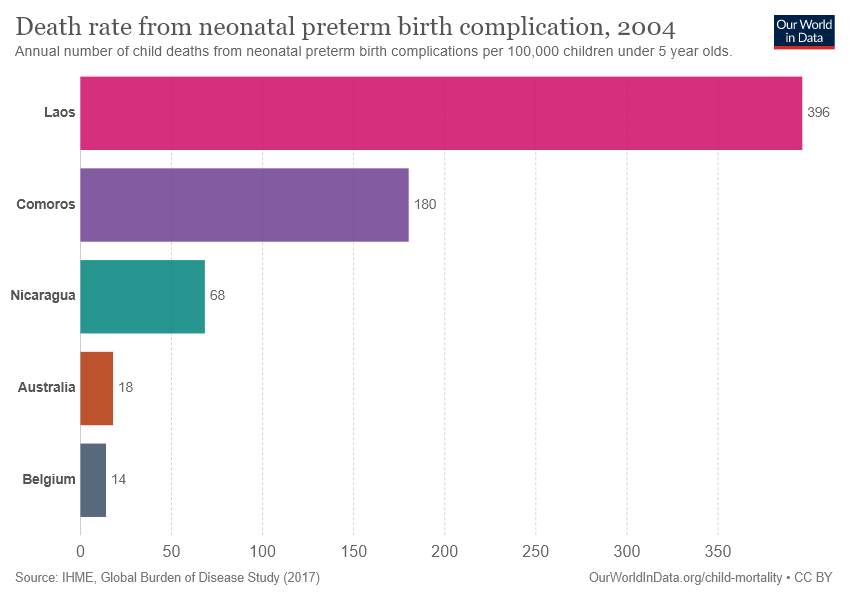

In [6]:
image

## Ask questions

In [8]:
inputs = processor(images=image, text="Is the sum of all 4 places greater than Laos?", return_tensors="pt")
predictions = model.generate(**inputs, max_new_tokens=512)

In [9]:
print(processor.decode(predictions[0], skip_special_tokens=True))

Country | Death rate from neonatal preterm birth complication, 2004 <0x0A> Laos | 396 <0x0A> Comoros | 180 <0x0A> Nicaragua | 68 <0x0A> Australia | 18 <0x0A> Belgium | 14


In [13]:
inputs = processor(images=image, text="What is Death rate in Laos?", return_tensors="pt")
predictions = model.generate(**inputs, max_new_tokens=8)

In [14]:
print(processor.decode(predictions[0], skip_special_tokens=True))

Country | Death rate from neonatal
